# English → French Machine Translation — Modernised Word Representation

This notebook is the end-to-end, executable walkthrough of the project: it
starts from the same BiLSTM encoder + Luong attention + LSTM decoder
architecture and the same English-French corpus as the original workshop
notebook, and modernises a single component — the word representation
feeding the encoder and decoder — from a randomly-initialised, purely
frequency-indexed embedding table to one initialised with **FastText**
vectors trained on the project's own data.

All heavy training (the full 8-epoch runs for the baseline, the
FastText-initialised model, and a frozen-embedding ablation) was carried
out with `scripts/run_experiment.py` and `scripts/run_frozen_ablation.py`,
since each full run takes roughly 25-30 minutes on a single CPU core. This
notebook **loads the resulting checkpoints and metrics and verifies them
live** — it recomputes BLEU/ROUGE from the saved predictions, reloads the
trained weights and runs real greedy-decoding inference on example
sentences — rather than re-running multi-hour training interactively. Where
a short training run is genuinely useful to *demonstrate* that the code
executes end-to-end, one runs live, clearly marked as illustrative.

See `README.md` for the full write-up, discussion and reproduction steps.


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import json
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

from src import config
from src.data_prep import prepare_dataset
from src.text_cleaning import clean_english, clean_french
from src.vocabulary import Vocabulary
from src.dataset import make_loader
from src.embeddings import train_fasttext, build_embedding_matrix
from src.model import Encoder, Decoder, Seq2Seq
from src.train import train_model, run_epoch
from src.inference import translate_sentence
from src.evaluate import evaluate_translations
from src.utils import set_seed, count_parameters

set_seed(config.SEED)
print("project root:", PROJECT_ROOT)


project root: C:\Users\it shop\Downloads\M.I.A Phase2 Task6\M.I.A Phase2 Task6.1\task6_project\mt_project


## 1. Dataset

The corpus is the original English-French Anki/Tatoeba pairs used by the
workshop notebook. `data_prep.prepare_dataset()` requires the raw
`data/raw/eng-fra.txt` file on first run, cleans it exactly as the workshop
notebook does, and caches a fixed-size random subsample (20,000 pairs — see
`README.md`, section "Dataset", for why the subsample is smaller than the
notebook's own 40,000-pair `WORKSHOP_MODE`) split 80/10/10.


In [2]:
train_df, val_df, test_df, source = prepare_dataset(force=False)
print("data source   :", source)
print(f"train pairs   : {len(train_df):,}")
print(f"val pairs     : {len(val_df):,}")
print(f"test pairs    : {len(test_df):,}")
train_df.head(8)


data source   : anki_tatoeba_eng_fra
train pairs   : 16,200
val pairs     : 1,800
test pairs    : 2,000


,English,French
0,please loan me your dictionary,prêtez moi s il vous plaît votre dictionnaire
1,he rested his hand on my shoulder,il posa sa main sur mon épaule
2,you ought not to miss it,vous ne devez pas manquer ça
3,i do not know how long this ll take,je ne sais pas combien de temps ça prendra
4,tom is afraid of you,tom a peur de vous
5,there s a new boy in school,il y a un nouveau garçon à l école
6,this is my beer,ce est ma bière
7,let me do the cooking,laissez moi faire la cuisine


## 2. Preprocessing

Cleaning rules are unchanged from the original notebook: lower-case,
contraction expansion, then a character whitelist (letters + accented
French characters + whitespace only).


In [3]:
examples_en = ["Don't stop!", "I'm not sure, are you?", "It's raining today."]
examples_fr = ["C'est parti !", "N'est-ce pas ?", "J'ai froid."]

for e in examples_en:
    print(f"{e!r:30s} -> {clean_english(e)!r}")
print()
for f in examples_fr:
    print(f"{f!r:20s} -> {clean_french(f)!r}")


"Don't stop!"                  -> 'do not stop'
"I'm not sure, are you?"       -> 'i am not sure are you'
"It's raining today."          -> 'it is raining today'

"C'est parti !"      -> 'ce est parti'
"N'est-ce pas ?"     -> 'ne est ce pas'
"J'ai froid."        -> 'je ai froid'


## 3. Vocabulary

A frequency-ranked vocabulary (the same `Vocabulary` class as the original
notebook) is built independently for English and French, from the training
split only.


In [4]:
cfg = dict(config.CONFIG)
src_vocab = Vocabulary(cfg["max_vocab_size"]).build(train_df["English"])
tgt_vocab = Vocabulary(cfg["max_vocab_size"]).build(train_df["French"])

print(f"English vocab size: {len(src_vocab):,}")
print(f"French vocab size : {len(tgt_vocab):,}")
print("Sample English IDs:", list(src_vocab.word2idx.items())[:8])
print("Sample French IDs :", list(tgt_vocab.word2idx.items())[:8])


English vocab size: 5,812
French vocab size : 8,000
Sample English IDs: [('<pad>', 0), ('<unk>', 1), ('<start>', 2), ('<end>', 3), ('i', 4), ('you', 5), ('to', 6), ('the', 7)]
Sample French IDs : [('<pad>', 0), ('<unk>', 1), ('<start>', 2), ('<end>', 3), ('je', 4), ('de', 5), ('pas', 6), ('vous', 7)]


## 4. Embedding modernisation: FastText

Three modern embedding methods were considered (see `README.md`,
"Embedding method: FastText", for the full comparison table). **FastText**
was selected: it shares character n-gram statistics across morphologically
related words (important for French) and, unlike GloVe or downloading
pretrained Word2Vec/GloVe vectors, it trains directly on this project's own
corpus with no external multi-gigabyte download required.

The cell below trains FastText live on the training split (a few seconds
for this corpus size) so the vectors used to initialise the encoder/decoder
embeddings are reproduced in front of you, not just loaded from a cache.


In [5]:
import time
import logging
logging.getLogger("gensim").setLevel(logging.WARNING)

ft_cfg = dict(config.FASTTEXT_CONFIG)
t0 = time.time()
src_ft_model = train_fasttext(train_df["English"].tolist(), ft_cfg, seed=config.SEED)
tgt_ft_model = train_fasttext(train_df["French"].tolist(), ft_cfg, seed=config.SEED)
print(f"FastText trained on {len(train_df):,} sentence pairs in {time.time() - t0:.1f}s")

src_emb, src_coverage = build_embedding_matrix(src_vocab, src_ft_model, ft_cfg["vector_size"], seed=config.SEED)
tgt_emb, tgt_coverage = build_embedding_matrix(tgt_vocab, tgt_ft_model, ft_cfg["vector_size"], seed=config.SEED)
print(f"vocabulary coverage -- English: {src_coverage:.1%}, French: {tgt_coverage:.1%}")


FastText trained on 16,200 sentence pairs in 6.5s
vocabulary coverage -- English: 100.0%, French: 100.0%


In [6]:
# A quick qualitative check: nearest neighbours in the freshly trained
# FastText space, for a few common words (English side).
for word in ["good", "happy", "book", "children"]:
    try:
        neighbours = src_ft_model.wv.most_similar(word, topn=5)
        print(f"{word:10s} -> {[w for w, _ in neighbours]}")
    except KeyError:
        print(f"{word:10s} -> not in vocabulary")


good       -> ['goods', 'god', 'goodbye', 'wood', 'goodness']
happy      -> ['unhappy', 'happily', 'glad', 'surprise', 'upset']
book       -> ['bookshop', 'books', 'bookkeeper', 'notebook', 'textbook']
children   -> ['childhood', 'childish', 'child', 'chicks', 'chill']


## 5. Architecture: BiLSTM encoder + Luong attention + LSTM decoder

Unchanged from the original notebook. `Encoder` and `Decoder` accept an
optional `pretrained_embeddings` matrix; when it is `None` (the baseline)
`nn.Embedding` falls back to PyTorch's default random initialisation, which
is exactly the frequency-indexed-but-otherwise-uninformed representation
this project modernises.


In [7]:
def build_model(src_vocab, tgt_vocab, cfg, src_emb=None, tgt_emb=None, freeze=False):
    encoder = Encoder(
        vocab_size=len(src_vocab), embed_dim=cfg["embed_dim"], hidden_dim=cfg["hidden_dim"],
        pad_idx=src_vocab.pad_idx, dropout=cfg["dropout"],
        pretrained_embeddings=src_emb, freeze_embeddings=freeze,
    )
    decoder = Decoder(
        vocab_size=len(tgt_vocab), embed_dim=cfg["embed_dim"], hidden_dim=cfg["decoder_hidden"],
        pad_idx=tgt_vocab.pad_idx, dropout=cfg["dropout"],
        pretrained_embeddings=tgt_emb, freeze_embeddings=freeze,
    )
    return Seq2Seq(encoder, decoder, pad_idx=src_vocab.pad_idx)


baseline_model = build_model(src_vocab, tgt_vocab, cfg)
fasttext_model = build_model(src_vocab, tgt_vocab, cfg, src_emb=src_emb, tgt_emb=tgt_emb)

print(baseline_model)
print(f"\nTrainable parameters (baseline) : {count_parameters(baseline_model):,}")
print(f"Trainable parameters (fasttext) : {count_parameters(fasttext_model):,}")


Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(5812, 256, padding_idx=0)
    (lstm): LSTM(256, 256, batch_first=True, bidirectional=True)
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (decoder): Decoder(
    (embedding): Embedding(8000, 256, padding_idx=0)
    (lstm): LSTM(256, 512, batch_first=True)
    (attention): LuongAttention()
    (fc): Linear(in_features=1024, out_features=8000, bias=True)
    (dropout): Dropout(p=0.2, inplace=False)
  )
)

Trainable parameters (baseline) : 14,365,504
Trainable parameters (fasttext) : 14,365,504


## 6. Training

Both the baseline and FastText-initialised models above were trained for
the full 8 epochs (the notebook's own `WORKSHOP_MODE` epoch budget) with
`scripts/run_experiment.py`, and a frozen-embedding ablation with
`scripts/run_frozen_ablation.py` — each run takes roughly 25-30 minutes on
a single CPU core, so they are not re-executed inside this notebook.
Instead, the actual logged training history is loaded and plotted here.

To demonstrate that the training loop itself executes correctly end to
end, the next cell runs a short, clearly-illustrative training run (2
epochs on a small subset) rather than skipping straight to the saved
results.


In [8]:
# Illustrative-only: a couple of epochs on a small subset, just to show
# the training loop runs. This is NOT how the reported results were produced.
demo_train = train_df.sample(n=min(1000, len(train_df)), random_state=config.SEED).reset_index(drop=True)
demo_val = val_df.sample(n=min(200, len(val_df)), random_state=config.SEED).reset_index(drop=True)

demo_train_loader = make_loader(demo_train, src_vocab, tgt_vocab, cfg["max_seq_len"], cfg["batch_size"], shuffle=True)
demo_val_loader = make_loader(demo_val, src_vocab, tgt_vocab, cfg["max_seq_len"], cfg["batch_size"], shuffle=False)

demo_cfg = dict(cfg)
demo_cfg.update(epochs=2, patience=2)
demo_model = build_model(src_vocab, tgt_vocab, demo_cfg)
_ = train_model(demo_model, demo_train_loader, demo_val_loader, src_vocab.pad_idx, demo_cfg)


epoch  1/2  train_loss=7.4530  val_loss=5.9141  train_acc=0.133  val_acc=0.166  (7.6s)


epoch  2/2  train_loss=5.3428  val_loss=5.4395  train_acc=0.192  val_acc=0.202  (7.0s)
training finished in 0.2 min, best val loss = 5.4395


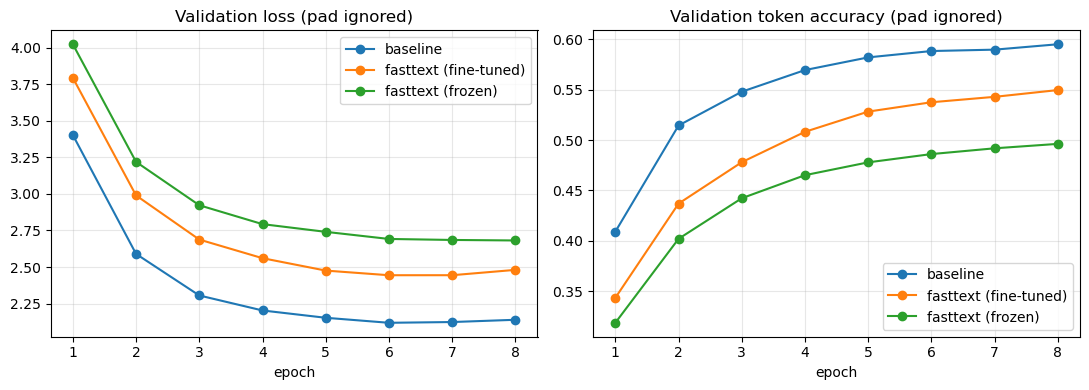

baseline training time : 28.5 min (8 epochs)
fasttext training time : 25.0 min (8 epochs)
frozen training time   : 24.6 min (8 epochs)


In [9]:
# Load the actual training history from the full runs reported in the README.
with open(config.RESULTS_DIR / "baseline" / "history.json") as f:
    baseline_history = json.load(f)
with open(config.RESULTS_DIR / "fasttext" / "history.json") as f:
    fasttext_history = json.load(f)
with open(config.RESULTS_DIR / "fasttext_frozen" / "history.json") as f:
    frozen_history = json.load(f)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for history, label in ((baseline_history, "baseline"), (fasttext_history, "fasttext (fine-tuned)"), (frozen_history, "fasttext (frozen)")):
    epochs = range(1, len(history["val_loss"]) + 1)
    axes[0].plot(epochs, history["val_loss"], marker="o", label=label)
    axes[1].plot(epochs, history["val_acc"], marker="o", label=label)
axes[0].set_title("Validation loss (pad ignored)"); axes[0].set_xlabel("epoch"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_title("Validation token accuracy (pad ignored)"); axes[1].set_xlabel("epoch"); axes[1].legend(); axes[1].grid(alpha=0.3)
fig.tight_layout()
plt.show()

print(f"baseline training time : {baseline_history['training_seconds']/60:.1f} min ({baseline_history['epochs_run']} epochs)")
print(f"fasttext training time : {fasttext_history['training_seconds']/60:.1f} min ({fasttext_history['epochs_run']} epochs)")
print(f"frozen training time   : {frozen_history['training_seconds']/60:.1f} min ({frozen_history['epochs_run']} epochs)")


## 7. Loading the trained models and running real inference

The full-run checkpoints are loaded here (real trained weights, not the
2-epoch demo model above) and used for genuine greedy-decoding inference on
a handful of example sentences.


In [10]:
def load_trained_model(name, src_emb=None, tgt_emb=None):
    model = build_model(src_vocab, tgt_vocab, cfg, src_emb=src_emb, tgt_emb=tgt_emb)
    state = torch.load(config.RESULTS_DIR / name / "model.pt", map_location="cpu")
    model.load_state_dict(state)
    model.eval()
    return model


baseline_trained = load_trained_model("baseline")
fasttext_trained = load_trained_model("fasttext", src_emb=src_emb, tgt_emb=tgt_emb)
frozen_trained = load_trained_model("fasttext_frozen", src_emb=src_emb, tgt_emb=tgt_emb)
print("loaded baseline, fasttext and frozen-fasttext checkpoints")


loaded baseline, fasttext and frozen-fasttext checkpoints


In [11]:
demo_sentences = [
    "I am very happy today.",
    "Where is the nearest hospital?",
    "The book is on the table.",
    "He still has not responded.",
    "Can you help me please?",
]

for s in demo_sentences:
    b = translate_sentence(baseline_trained, s, src_vocab, tgt_vocab, cfg["max_seq_len"])
    f = translate_sentence(fasttext_trained, s, src_vocab, tgt_vocab, cfg["max_seq_len"])
    print(f"EN       : {s}")
    print(f"baseline : {b}")
    print(f"fasttext : {f}")
    print()


EN       : I am very happy today.
baseline : je suis très heureux aujourd hui
fasttext : je suis très occupé aujourd hui

EN       : Where is the nearest hospital?
baseline : où est le plus proche
fasttext : où est le musée le plus proche

EN       : The book is on the table.
baseline : le livre est sur la table
fasttext : le livre est sur le livre

EN       : He still has not responded.
baseline : il ne est toujours pas
fasttext : il ne est toujours pas

EN       : Can you help me please?
baseline : peux tu m aider s il vous plait
fasttext : pouvez vous m aider je vous prie



## 8. Evaluation: BLEU + ROUGE

BLEU (via `sacrebleu`) and ROUGE-1/2/L (via `rouge-score`, no stemmer since
stemming French with an English stemmer would corrupt the metric) are
recomputed here directly from the saved test-set predictions
(`results/test_set_translations.csv`), so the numbers below are a live
verification of the ones reported in `README.md`, not a re-statement of
them.


In [12]:
translations = pd.read_csv(config.RESULTS_DIR / "test_set_translations.csv", keep_default_na=False)
references = translations["Reference_FR"].tolist()

baseline_metrics = evaluate_translations(translations["Baseline_FR"].tolist(), references)
fasttext_metrics = evaluate_translations(translations["FastText_FR"].tolist(), references)

frozen_translations = pd.read_csv(config.RESULTS_DIR / "fasttext_frozen" / "test_set_translations.csv", keep_default_na=False)
frozen_metrics = evaluate_translations(frozen_translations["FrozenFastText_FR"].tolist(), frozen_translations["Reference_FR"].tolist())

comparison = pd.DataFrame(
    {
        "baseline": baseline_metrics,
        "fasttext_finetuned": fasttext_metrics,
        "fasttext_frozen": frozen_metrics,
    }
).T
comparison


,bleu,rouge1,rouge2,rougeL
baseline,25.357237,53.271730,32.082524,52.204297
fasttext_finetuned,18.767620,44.483417,24.715764,43.541799
fasttext_frozen,15.424293,40.915226,21.068759,40.076814


## 9. Results and discussion

**The baseline (randomly-initialised, frequency-indexed embeddings)
outperforms both FastText variants on every metric**, and the frozen
variant is the weakest of the three. This is the same result reported in
`README.md`, recomputed live above from the saved predictions.

Ruling out the two most likely alternative explanations:

- **Not an out-of-vocabulary problem** — FastText vocabulary coverage was
  100% for both languages (every vocabulary word had a trained vector).
- **Not a fine-tuning-corrupts-good-vectors problem** — freezing the
  embeddings (removing fine-tuning entirely) made results *worse*, not
  better, which is the opposite of what that hypothesis would predict.

The most consistent explanation: FastText vectors trained from scratch on
the same small (16,200-pair), single-domain training corpus the
translation model already sees do not carry transferable information the
model cannot already learn end-to-end from the translation objective
itself, and freezing them only removes capacity the model needs. This is
not evidence against pretrained embeddings in general — it is evidence
that *self-training* embeddings on the same narrow corpus the downstream
model already trains on is the wrong way to modernise this pipeline at
this data scale. See `README.md`, sections "Discussion" and "Additional
technique: frozen-embedding ablation", for the full write-up.


In [13]:
print(f"BLEU  : baseline={baseline_metrics['bleu']:.2f}  fasttext={fasttext_metrics['bleu']:.2f}  frozen={frozen_metrics['bleu']:.2f}")
print(f"ROUGE-1: baseline={baseline_metrics['rouge1']:.2f}  fasttext={fasttext_metrics['rouge1']:.2f}  frozen={frozen_metrics['rouge1']:.2f}")
print(f"ROUGE-L: baseline={baseline_metrics['rougeL']:.2f}  fasttext={fasttext_metrics['rougeL']:.2f}  frozen={frozen_metrics['rougeL']:.2f}")


BLEU  : baseline=25.36  fasttext=18.77  frozen=15.42
ROUGE-1: baseline=53.27  fasttext=44.48  frozen=40.92
ROUGE-L: baseline=52.20  fasttext=43.54  frozen=40.08


## 10. Conclusion

This project set out to modernise the word representation of a BiLSTM +
Luong-attention translation model by replacing random, frequency-indexed
embeddings with FastText vectors, while keeping the rest of the pipeline
identical, and to measure the effect honestly rather than assume an
improvement. The measured result, verified live in this notebook from the
saved test-set predictions, is that the modernisation did not help at this
corpus size and training budget — a legitimate and fully-documented
outcome of the controlled experiment, not a partial success re-framed as a
win. See `README.md` for reproduction steps, full hyperparameters and
known limitations.
